Dataset size: 15000
Class distribution:
label
0    7500
1    7500
Name: count, dtype: int64
Train: 10800, Val: 1200, Test: 3000
Fitting feature union on training data...
Training feature shape: (10800, 12637)
Training XGBoost...
[0]	validation_0-logloss:0.65845	validation_1-logloss:0.65800
[1]	validation_0-logloss:0.62698	validation_1-logloss:0.62651
[2]	validation_0-logloss:0.59843	validation_1-logloss:0.59782
[3]	validation_0-logloss:0.57221	validation_1-logloss:0.57161
[4]	validation_0-logloss:0.54838	validation_1-logloss:0.54743
[5]	validation_0-logloss:0.52655	validation_1-logloss:0.52534
[6]	validation_0-logloss:0.50623	validation_1-logloss:0.50489
[7]	validation_0-logloss:0.48739	validation_1-logloss:0.48619
[8]	validation_0-logloss:0.46982	validation_1-logloss:0.46888
[9]	validation_0-logloss:0.45359	validation_1-logloss:0.45285
[10]	validation_0-logloss:0.43852	validation_1-logloss:0.43774
[11]	validation_0-logloss:0.42436	validation_1-logloss:0.42371
[12]	validation_0-logloss

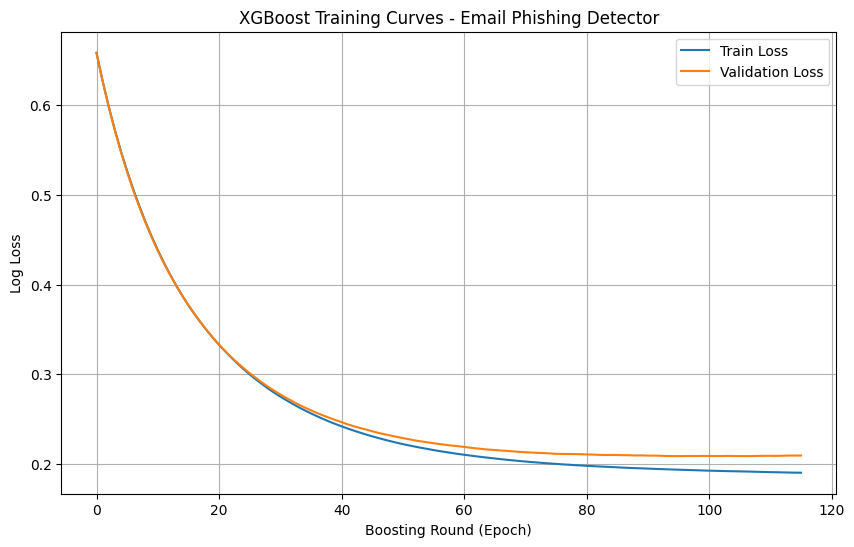


Classification Report (Test Set):
              precision    recall  f1-score   support

  Legitimate       0.82      0.90      0.86      1500
    Phishing       0.89      0.81      0.85      1500

    accuracy                           0.85      3000
   macro avg       0.86      0.85      0.85      3000
weighted avg       0.86      0.85      0.85      3000

F1 Score: 0.8469


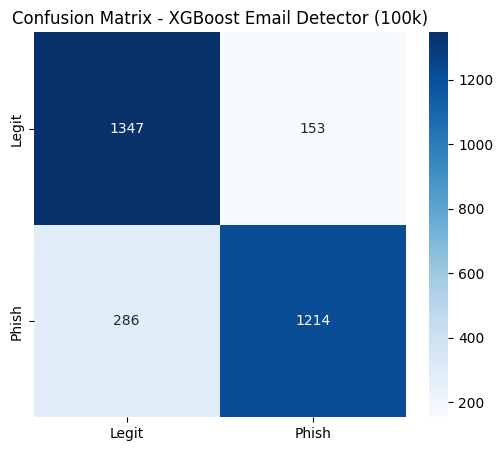

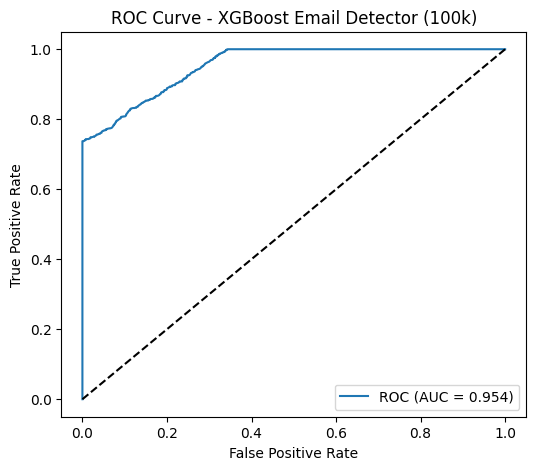

Full pipeline saved as phishing_xgboost_100k.pkl


In [13]:
import pandas as pd
import numpy as np
import joblib
import re
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_curve, auc
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.base import BaseEstimator, TransformerMixin
import xgboost as xgb

# ==========================
# 1. Load dataset (100k)
# ==========================
df = pd.read_csv("combined_phishing_dataset_15000.csv")

# Convert text to plain Python strings (fix Arrow issue)
df['text'] = df['text'].astype(str).tolist()

# Drop rows with missing text or label
df = df.dropna(subset=['text', 'label'])

# ==========================
# 2. Label mapping (robust)
# ==========================
# Convert label to string first, then map
df['label'] = df['label'].astype(str)
label_map = {'Safe': 0, 'Legitimate': 0, 'Phishing': 1}
# If there are other labels, map to 0 or 1 accordingly; unknown labels become 0
df['label'] = df['label'].map(label_map).fillna(0).astype(int)

print(f"Dataset size: {len(df)}")
print(f"Class distribution:\n{df['label'].value_counts()}")

# ==========================
# 3. Feature engineering
# ==========================
def entropy(s):
    if len(s) == 0:
        return 0
    prob = [s.count(c)/len(s) for c in set(s)]
    return -sum(p * math.log2(p) for p in prob)

def extra_features(text):
    features = {}
    features['length'] = len(text)
    features['num_digits'] = sum(c.isdigit() for c in text)
    features['num_special'] = sum(not c.isalnum() and not c.isspace() for c in text)
    features['num_urls'] = len(re.findall(r'https?://\S+|www\.\S+', text))
    features['num_exclamations'] = text.count('!')
    features['num_uppercase_words'] = sum(1 for w in text.split() if w.isupper() and len(w)>1)
    features['entropy'] = entropy(text)
    
    suspicious_en = ['verify','account','login','update','bank','paypal','secure','click','confirm','urgent','password']
    suspicious_ne = ['खाता','प्रमाणित','लगइन','अपडेट','बैंक','सुरक्षित','क्लिक','पुष्टि','अत्यावश्यक','पासवर्ड']
    features['has_suspicious'] = int(any(kw in text.lower() for kw in suspicious_en) or
                                     any(kw in text for kw in suspicious_ne))
    return features

class ExtraFeaturesTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        # X is a list of strings
        return pd.DataFrame([extra_features(t) for t in X]).values

# ==========================
# 4. Split data (train/val/test)
# ==========================
X = df['text'].tolist()          # plain Python list
y = df['label'].tolist()         # plain Python list

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1, random_state=42, stratify=y_train_val
)
print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# ==========================
# 5. Feature union (char + word + extra)
# ==========================
char_vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(2, 6),
    max_features=20000,
    sublinear_tf=True,
    lowercase=True
)

word_vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=10000,
    sublinear_tf=True,
    lowercase=True,
    stop_words='english'
)

combined = FeatureUnion([
    ('char', char_vectorizer),
    ('word', word_vectorizer),
    ('extra', ExtraFeaturesTransformer())
])

# ==========================
# 6. Transform to sparse matrix
# ==========================
print("Fitting feature union on training data...")
combined.fit(X_train)

X_train_feat = combined.transform(X_train)
X_val_feat = combined.transform(X_val)
X_test_feat = combined.transform(X_test)

print(f"Training feature shape: {X_train_feat.shape}")

# ==========================
# 7. XGBoost with early stopping
# ==========================
model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    early_stopping_rounds=20
)

eval_set = [(X_train_feat, y_train), (X_val_feat, y_val)]
print("Training XGBoost...")
model.fit(X_train_feat, y_train, eval_set=eval_set, verbose=True)

# ==========================
# 8. Training curves (loss vs boosting rounds)
# ==========================
results = model.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(10,6))
plt.plot(x_axis, results['validation_0']['logloss'], label='Train Loss')
plt.plot(x_axis, results['validation_1']['logloss'], label='Validation Loss')
plt.xlabel('Boosting Round (Epoch)')
plt.ylabel('Log Loss')
plt.title('XGBoost Training Curves - Email Phishing Detector')
plt.legend()
plt.grid(True)
plt.savefig('email_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================
# 9. Evaluation on test set
# ==========================
y_pred = model.predict(X_test_feat)
y_proba = model.predict_proba(X_test_feat)[:,1]

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=['Legitimate','Phishing']))
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit','Phish'], yticklabels=['Legit','Phish'])
plt.title('Confusion Matrix - XGBoost Email Detector (100k)')
plt.savefig('email_cm_100k.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost Email Detector (100k)')
plt.legend()
plt.savefig('email_roc_100k.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================
# 10. Save full pipeline
# ==========================
full_pipeline = Pipeline([
    ('features', combined),
    ('clf', model)
])
joblib.dump(full_pipeline, 'phishing_xgboost_100k.pkl')
print("Full pipeline saved as phishing_xgboost_100k.pkl")

In [14]:
import joblib

class EmailDetector:
    def __init__(self, model_path='models/email/phishing_xgboost_100k.pkl'):
        self.pipeline = joblib.load(model_path)

    def predict(self, email_text):
        pred = self.pipeline.predict([email_text])[0]
        proba = self.pipeline.predict_proba([email_text])[0].max()
        label = 'phishing' if pred == 1 else 'legitimate'
        return {'label': label, 'confidence': proba, 'module': 'email'}